İlk olarak kaggle üzerinden belirlediğimiz veri setini indiren ve ilk beş satırını yazdıran kod bloğunu oluşturuyoruz.

In [26]:
!pip install kagglehub --quiet

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = kagglehub.dataset_download("tunguz/online-retail")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# Verinin dataframe olarak yüklenmesi (Yaygın e-ticaret encoding'i ile)
df = pd.read_csv(full_path, encoding="ISO-8859-1")

print(df.info())
df.head()

Using Colab cache for faster access to the 'online-retail' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


Veri setindeki eksik müşteri numaralarını temizliyoruz, iade edilen siparişleri veri setinden çıkarıyoruz, miktar ve fiyat sütunlarındaki hatalı/negatif değerleri filtreliyoruz ve tarih sütununu uygun formata dönüştürüyoruz.

In [27]:
# Eksik CustomerID satırlarının silinmesi
df_cleaned = df.dropna(subset=['CustomerID']).copy()

# Tarih sütununun datetime formatına çevrilmesi
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'], format='%m/%d/%y %H:%M')

# İptal edilen (Fatura kodu 'C' ile başlayan) işlemlerin elenmesi
df_cleaned = df_cleaned[~df_cleaned['InvoiceNo'].astype(str).str.startswith('C')]

# Miktar ve birim fiyatı 0'dan büyük olan geçerli işlemlerin filtrelenmesi
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['UnitPrice'] > 0)]

# Temizlik sonrası veri boyutunun kontrol edilmesi
print(f"Orijinal Veri Boyutu: {df.shape}")
print(f"Temizlenmiş Veri Boyutu: {df_cleaned.shape}")

Orijinal Veri Boyutu: (541909, 8)
Temizlenmiş Veri Boyutu: (397884, 8)


Analizlerde kullanmak üzere toplam harcama tutarını hesaplıyoruz ve zamansal trendleri inceleyebilmek için tarih sütunundan saat ile gün bilgilerini yeni sütunlar olarak çıkarıyoruz.

In [29]:
# Satış bazlı toplam tutarın hesaplanması
df_cleaned['TotalAmount'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

# Zaman bazlı analizler için saat ve gün bilgilerinin çıkarılması
df_cleaned['Hour'] = df_cleaned['InvoiceDate'].dt.hour
df_cleaned['DayOfWeek'] = df_cleaned['InvoiceDate'].dt.day_name()

# Günlerin grafikte kronolojik sıralanması için kategori düzenlemesi
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
df_cleaned['DayOfWeek'] = pd.Categorical(df_cleaned['DayOfWeek'], categories=days_order, ordered=True)

# Eklenen sütunların kontrol edilmesi
df_cleaned[['InvoiceDate', 'TotalAmount', 'Hour', 'DayOfWeek']].head()

,InvoiceDate,TotalAmount,Hour,DayOfWeek
0,2010-12-01 08:26:00,15.30,8,Wednesday
1,2010-12-01 08:26:00,20.34,8,Wednesday
2,2010-12-01 08:26:00,22.00,8,Wednesday
3,2010-12-01 08:26:00,20.34,8,Wednesday
4,2010-12-01 08:26:00,20.34,8,Wednesday


## Keşifsel Veri Analizi (EDA)
Bu bölümde, veri setindeki satış trendlerini ve müşteri davranışlarını anlamak adına görselleştirmeler yapıyoruz. İlk olarak şirkete en çok ciro kazandıran ilk 10 ürünü tespit edip çubuk grafik (bar plot) ile görselleştiriyoruz.

/tmp/ipykernel_5021/575697105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


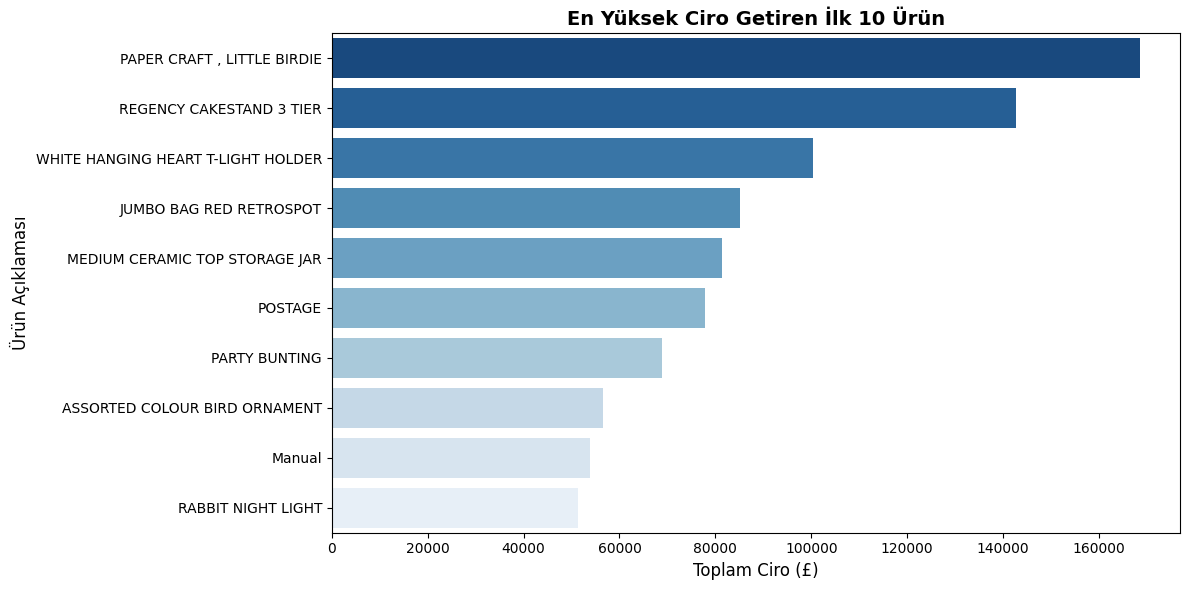

In [30]:
# Ürün bazında toplam cironun hesaplanması ve en yüksek 10 ürünün seçilmesi
top_products = df_cleaned.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)

# Grafik boyutunun ve stilinin ayarlanması
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')

# Grafik başlık ve etiketlerinin eklenmesi
plt.title('En Yüksek Ciro Getiren İlk 10 Ürün', fontsize=14, fontweight='bold')
plt.xlabel('Toplam Ciro (£)', fontsize=12)
plt.ylabel('Ürün Açıklaması', fontsize=12)
plt.tight_layout()
plt.show()

E-ticaret platformunun zaman içerisindeki toplam ciro değişimini gözlemlemek amacıyla aylık satış trendlerini hesaplıyoruz ve çizgi grafik (line plot) ile görselleştiriyoruz.

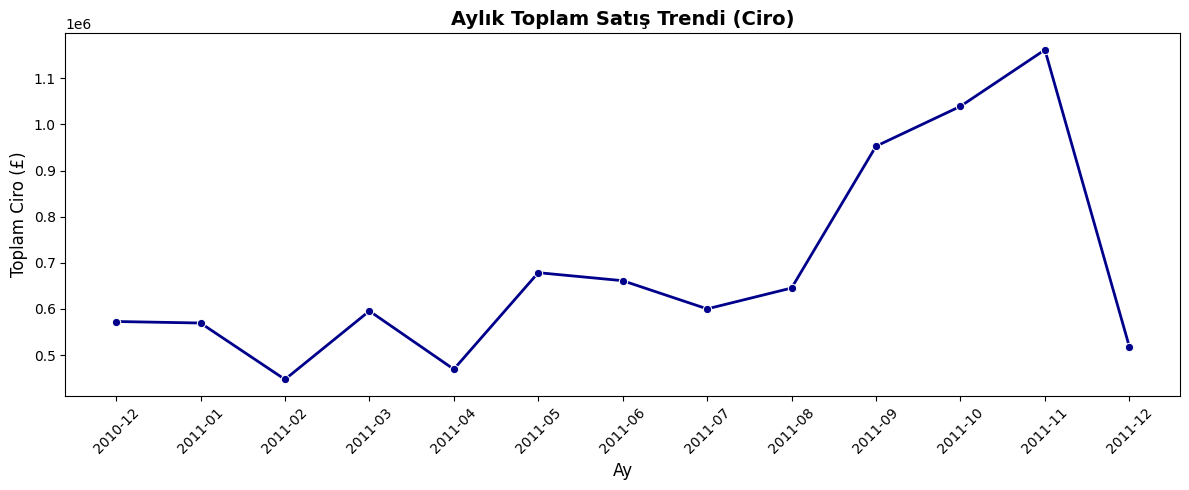

In [31]:
# Analiz için Month (Ay) sütununun oluşturulması
df_cleaned['Month'] = df_cleaned['InvoiceDate'].dt.to_period('M')

# Aylık bazda toplam cironun hesaplanması
monthly_sales = df_cleaned.groupby('Month')['TotalAmount'].sum().reset_index()

# Month sütununun grafikte düzgün basılması için stringe çevrilmesi
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# Grafik boyutunun ayarlanması
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Month', y='TotalAmount', marker='o', color='darkblue', linewidth=2)

# Grafik başlık ve etiketlerinin eklenmesi
plt.title('Aylık Toplam Satış Trendi (Ciro)', fontsize=14, fontweight='bold')
plt.xlabel('Ay', fontsize=12)
plt.ylabel('Toplam Ciro (£)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sipariş başına yapılan harcama tutarlarının genel dağılımını ve yoğunlaştığı aralıkları gözlemlemek amacıyla bir histogram çiziyoruz. Aşırı yüksek değerli işlemlerin dağılım görselini bozmaması için analizi 1000 £ altındaki siparişler ile sınırlandırıyoruz.

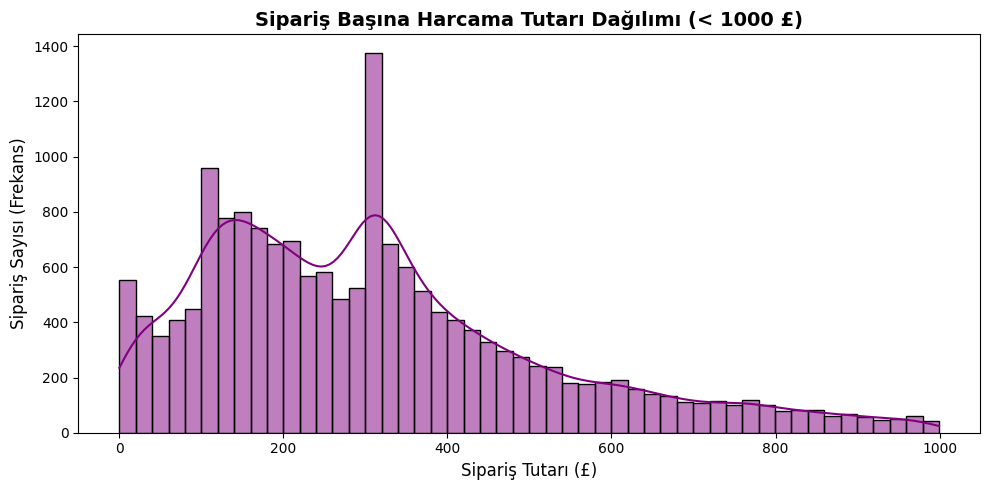

In [32]:
# Fatura başına toplam harcama tutarlarının hesaplanması
invoice_amounts = df_cleaned.groupby('InvoiceNo')['TotalAmount'].sum()

# Grafik boyutunun ayarlanması
plt.figure(figsize=(10, 5))

# 1000 £ altındaki siparişlerin dağılımının histogram ile çizilmesi
sns.histplot(invoice_amounts[invoice_amounts < 1000], bins=50, kde=True, color='purple')

# Grafik başlık ve etiketlerinin eklenmesi
plt.title('Sipariş Başına Harcama Tutarı Dağılımı (< 1000 £)', fontsize=14, fontweight='bold')
plt.xlabel('Sipariş Tutarı (£)', fontsize=12)
plt.ylabel('Sipariş Sayısı (Frekans)', fontsize=12)
plt.tight_layout()
plt.show()

Siparişlerin haftanın günlerine ve günün saatlerine göre yoğunluğunu bir arada görebilmek için iki boyutlu bir frekans matrisi oluşturuyoruz ve bunu ısı haritası (heatmap) ile görselleştiriyoruz.

/tmp/ipykernel_5021/3495343978.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = df_cleaned.groupby(['DayOfWeek', 'Hour'])['InvoiceNo'].nunique().unstack().fillna(0)


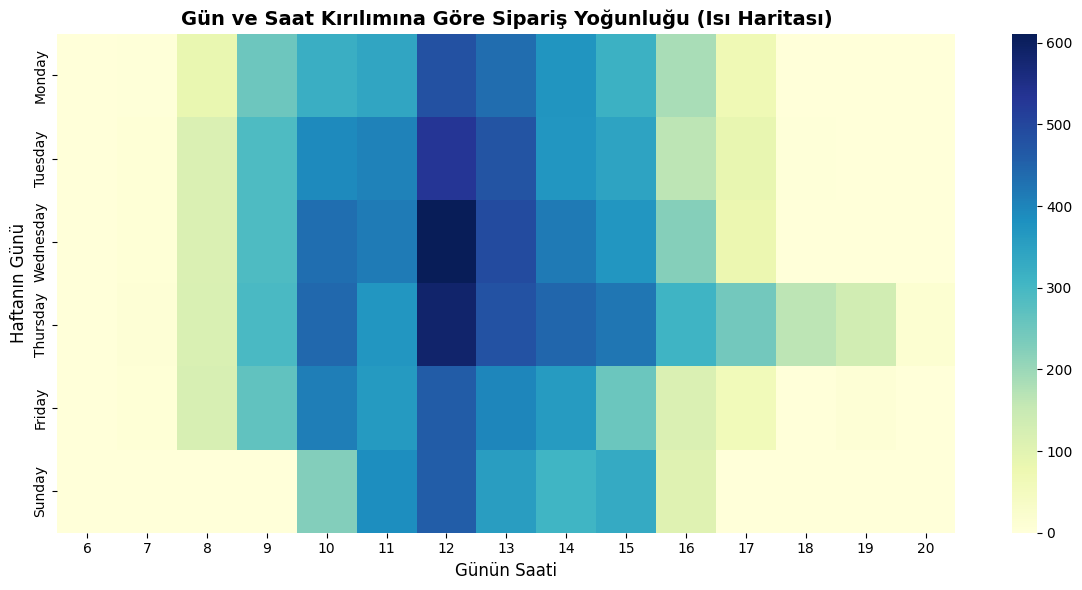

In [33]:
# Gün ve saat kırılımında benzersiz sipariş (InvoiceNo) sayılarının pivot tabloya dönüştürülmesi
pivot_table = df_cleaned.groupby(['DayOfWeek', 'Hour'])['InvoiceNo'].nunique().unstack().fillna(0)

# Grafik boyutunun ayarlanması
plt.figure(figsize=(12, 6))

# Isı haritasının çizilmesi (Yorum satırı uyarısı almamak için cmap kullanıldı)
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False, fmt='.0f')

# Grafik başlık ve etiketlerinin eklenmesi
plt.title('Gün ve Saat Kırılımına Göre Sipariş Yoğunluğu (Isı Haritası)', fontsize=14, fontweight='bold')
plt.xlabel('Günün Saati', fontsize=12)
plt.ylabel('Haftanın Günü', fontsize=12)
plt.tight_layout()
plt.show()

## K-Means ile Müşteri Segmentasyonu
Müşterileri satın alma davranışlarına göre gruplandırmak adına her bir müşterinin Recency (Son Satın Alma Zamanı), Frequency (Alışveriş Sıklığı) ve Monetary (Toplam Harcama) değerlerini hesaplıyoruz. Ardından bu metrikleri K-Means algoritmasına uygun hale getirmek için standartlaştırıyoruz.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Veri setindeki en son tarihi referans noktası olarak alma
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

# Müşteri bazında RFM metriklerinin hesaplanması
rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalAmount': 'sum'                                    # Monetary
}).reset_index()

# Sütun isimlerinin yeniden adlandırılması
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# K-Means algoritması varyansa duyarlı olduğu için verilerin standartlaştırılması
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Dönüştürülen verinin ilk 3 satırının kontrolü
print("RFM Metrikleri Başarıyla Hesaplandı ve Standartlaştırıldı:")
print(rfm[['Recency', 'Frequency', 'Monetary']].head(3))

RFM Metrikleri Başarıyla Hesaplandı ve Standartlaştırıldı:
   Recency  Frequency  Monetary
0      326          1  77183.60
1        2          7   4310.00
2       75          4   1797.24


K-Means modelinin müşterileri nasıl gruplandırdığını ve kümeler arasındaki sınırları görselleştirmek amacıyla Frequency (Sıklık) ve Monetary (Ciro) boyutlarında bir dağılım grafiği (scatter plot) oluşturuyoruz.

Küme (Segment) Bazında RFM Ortalamaları:
            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490




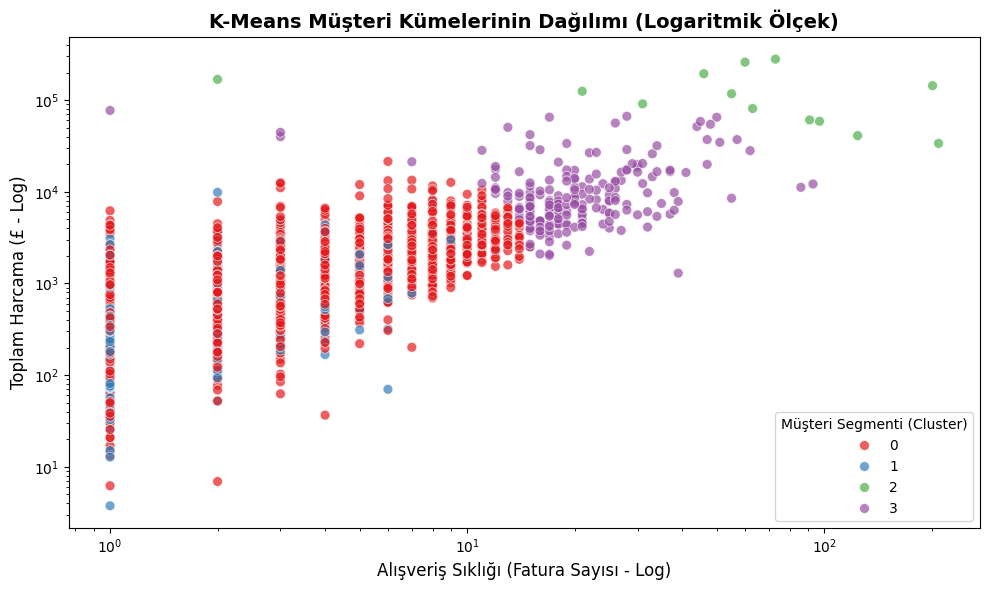

In [35]:
# 4 küme (segment) ile nihai modelin eğitilmesi
final_kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)

# rfm tablosuna Cluster sütununun eklenmesi (Hata alan sütun burada oluşturuluyor)
rfm['Cluster'] = final_kmeans.fit_predict(rfm_scaled)

# Küme bazında ortalama değerlerin kontrol edilmesi
print("Küme (Segment) Bazında RFM Ortalamaları:")
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())
print("\n" + "="*50 + "\n")

# --- Kümelerin Dağılım Grafiği (Scatter Plot) ---
plt.figure(figsize=(10, 6))

# Kümelere göre renklendirilmiş scatter plot çizimi
# hue uyarısını engellemek için hue_order yerine doğrudan hue=Cluster atandı
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    s=50
)

# Eksenlerin logaritmik olarak ölçeklendirilmesi
plt.xscale('log')
plt.yscale('log')

# Grafik başlık ve etiketlerinin eklenmesi
plt.title('K-Means Müşteri Kümelerinin Dağılımı (Logaritmik Ölçek)', fontsize=14, fontweight='bold')
plt.xlabel('Alışveriş Sıklığı (Fatura Sayısı - Log)', fontsize=12)
plt.ylabel('Toplam Harcama (£ - Log)', fontsize=12)
plt.legend(title='Müşteri Segmenti (Cluster)')
plt.tight_layout()
plt.show()

K-Means algoritması için en uygun küme (segment) sayısını belirlemek amacıyla Dirsek Yöntemi (Elbow Method) uyguluyoruz. Ardından seçilen optimum küme sayısı ile modeli eğiterek her müşteriyi bir segmente atıyoruz.

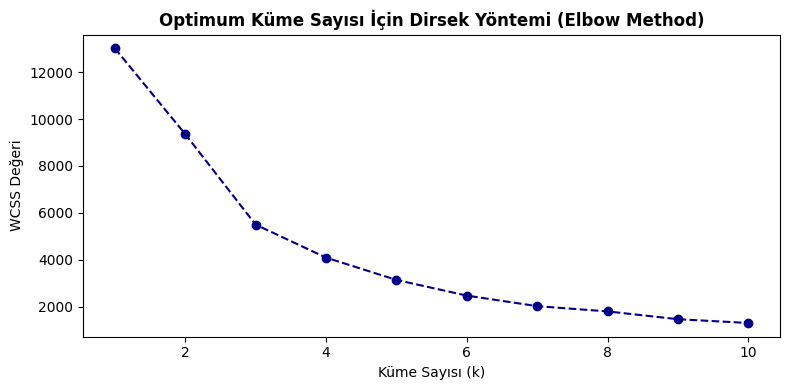


Küme (Segment) Bazında RFM Ortalamaları:
            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


In [36]:
# Farklı küme sayıları için WCSS (küme içi kareler toplamı) değerlerinin hesaplanması
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Dirsek Yöntemi grafiğinin çizilmesi
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Optimum Küme Sayısı İçin Dirsek Yöntemi (Elbow Method)', fontsize=12, fontweight='bold')
plt.xlabel('Küme Sayısı (k)', fontsize=10)
plt.ylabel('WCSS Değeri', fontsize=10)
plt.tight_layout()
plt.show()

# Grafik incelendiğinde kırılma noktası genellikle 3 veya 4 olur.
# Biz 4 küme (segment) ile nihai modelimizi eğitiyoruz.
final_kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = final_kmeans.fit_transform(rfm_scaled).argmin(axis=1) # En yakın kümeyi atama

# Küme bazında ortalama değerlerin kontrol edilmesi
print("\nKüme (Segment) Bazında RFM Ortalamaları:")
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

##Sonuçların Değerlendirilmesi ve Müşteri Segmentasyonu
K-Means modeli çıktısında oluşan 4 küme (Cluster), müşteri davranışlarına göre şu şekilde anlamlandırılmıştır:

Cluster 2 - Şampiyonlar (Sadık ve Yüksek Harcamalılar): Son alışverişleri çok yakın (ortalama 7 gün), alışveriş sıklıkları (82 fatura) ve bıraktıkları ciro (127.338 £) aşırı yüksektir. Şirketin en değerli kemik kitlesidir.

Cluster 3 - Sadık Müşteriler (Düzenli Alıcılar): Yakın zamanda (ortalama 15 gün) işlem yapmış, sıklıkları (22 fatura) ve bıraktıkları ciro (12.709 £) yüksek olan, sürekliliği sağlayan gruptur.

Cluster 0 - Yeni / Potansiyel Müşteriler: Son alışverişlerinin üzerinden ortalama 43 gün geçmiş, alışveriş sıklığı ve harcamaları standart düzeyde (1359 £) olan, doğru kampanyalarla sadık müşteriye dönüştürülebilecek gruptur.

Cluster 1 - Kaybedilen / Uykudaki Müşteriler: Son alışverişlerinin üzerinden 248 gün gibi uzun bir süre geçmiş, alışveriş sıklıkları (1.5) ve bıraktıkları ciro (480 £) en düşük olan, platformu neredeyse terk etmiş kitledir.